<a href="https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Students Performance in Exams Project

## Table of Contents

* [Project Summary](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=d2261c87&line=1&uniqifier=1)
* [1. Introduction & Data Loading](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=c18362ef)
* [2. Exploratory Data Analysis - EDA](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=61a52adf)
* [3. Analysis of Exam Scores by Demographic Characteristics](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=7013e1e6)
  * [3.1. Gender Impact](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=7013e1e6)
  * [3.2. The Impact of the Exam Preparation Course](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=4c63521b)
  * [3.3. Ethnic Origin Analysis](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=7b923837)
  * [3.4. Analysis of Parental Level of Education](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=7961bea3)
  * [3.5. The Effect of Lunch Type](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=81e76fab)
* [4. Relationships Between Scores (Correlation Analysis)](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=0347eec6)
* [5. General Conclusion and Evaluation](https://colab.research.google.com/github/SevdeColak/Data-Science-Portfolio/blob/main/Students_Performance_in_Exams.ipynb#scrollTo=c5b049a1)

## Project Summary

This project examines the factors influencing students' exam performance. The dataset includes students' demographic and socio-economic characteristics—such as **gender, ethnic background (group), parental education level, lunch type (standard or free/reduced)**, and **exam preparation course completion status**—alongside their exam scores in **mathematics, reading, and writing**.

### Scope of Analysis and Findings:
1. **Gender Impact:** It was observed that male students generally achieved higher averages in mathematics, while female students generally achieved higher averages in reading and writing.
2. **Exam Preparation Course:** Students who completed the exam preparation course were observed to perform significantly better across all subjects compared to those who did not take the course.
3. **Ethnic Background and Parental Education:** Students with highly educated parents (specifically those holding bachelor's or master's degrees) and those belonging to certain ethnic groups achieved higher average scores.
4. **Lunch Type:** It was determined that students receiving standard lunches performed better across all exam areas compared to students receiving free or reduced-price lunches.
5. **Strong Correlation:** There is an extremely strong positive relationship (correlation) between reading and writing scores.

## 1. Introduction & Data Loading

In this section, we import the libraries that will form the foundation of the project and incorporate the student performance dataset into our project by downloading it via KaggleHub.

In [ ]:
import kagglehub
path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

Using Colab cache for faster access to the 'students-performance-in-exams' dataset.


### Loading Libraries

We are loading the `pandas`, `numpy`, `matplotlib`, and `seaborn` libraries frequently used for data analysis, visualization, and statistical operations as well as the `plotly` library for interactive charts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv(path + "/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 2. Exploratory Data Analysis - EDA

At this stage, we examine the availability of the dataset, check for missing data, and review general summaries of the variables.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [ ]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [ ]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [ ]:
for column in df.columns[:5]:
    print(df[column].unique())
    print(df[column].value_counts())

['female' 'male']
gender
female    518
male      482
Name: count, dtype: int64
['group B' 'group C' 'group A' 'group D' 'group E']
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
['standard' 'free/reduced']
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
['none' 'completed']
test preparation course
none         642
completed    358
Name: count, dtype: int64


### Simplifying Variable Names

We rename the column names during the analysis process to facilitate coding and achieve cleaner syntax.

In [ ]:
df.rename(columns={
  "gender":"gender",
  "race/ethnicity":"race",
  "parental level of education":"parent_edu",
  "lunch":"lunch",
  "test preparation course":"prep_course",
  "math score":"math_score",
  "reading score":"reading_score",
  "writing score":"writing_score"
}, inplace=True)

df.head()

,gender,race,parent_edu,lunch,prep_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3. Analysis of Exam Scores by Demographic Characteristics

### 3.1. Gender Impact

First, we examine the impact of gender on mathematics, reading, and writing scores using box plots and group means.

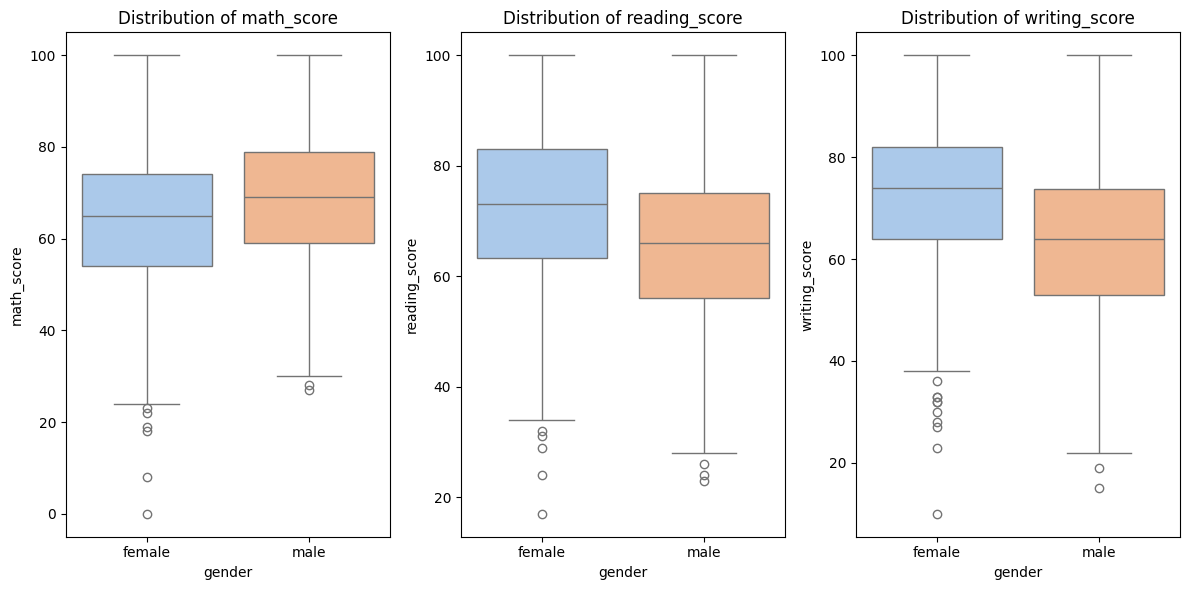

,math_score,reading_score,writing_score
gender,,,
female,63.633205,72.608108,72.467181
male,68.728216,65.473029,63.311203


In [ ]:
score_cols = ["math_score", "reading_score", "writing_score"]

plt.figure(figsize=(12, 6))
for i, col in enumerate(score_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df, x="gender", y=col, palette="pastel")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

df.groupby("gender")[score_cols].mean()

In [ ]:
df['average_score'] = (
    df['math_score'] +
    df['reading_score'] +
    df['writing_score']
) / 3

df.groupby('gender')['average_score'].mean()

,average_score
gender,
female,69.569498
male,65.837483


### 3.2. The Impact of the Exam Preparation Course

We examine the direct impact of completing the exam preparation course on students' achievement levels.

> **Key Findings (Gender):**
> * While male students have a higher average in mathematics, female students perform significantly better in reading and writing.
> * When looking at the overall average across the three subjects, the mean score of female students (69.57) is higher than that of male students (65.84).

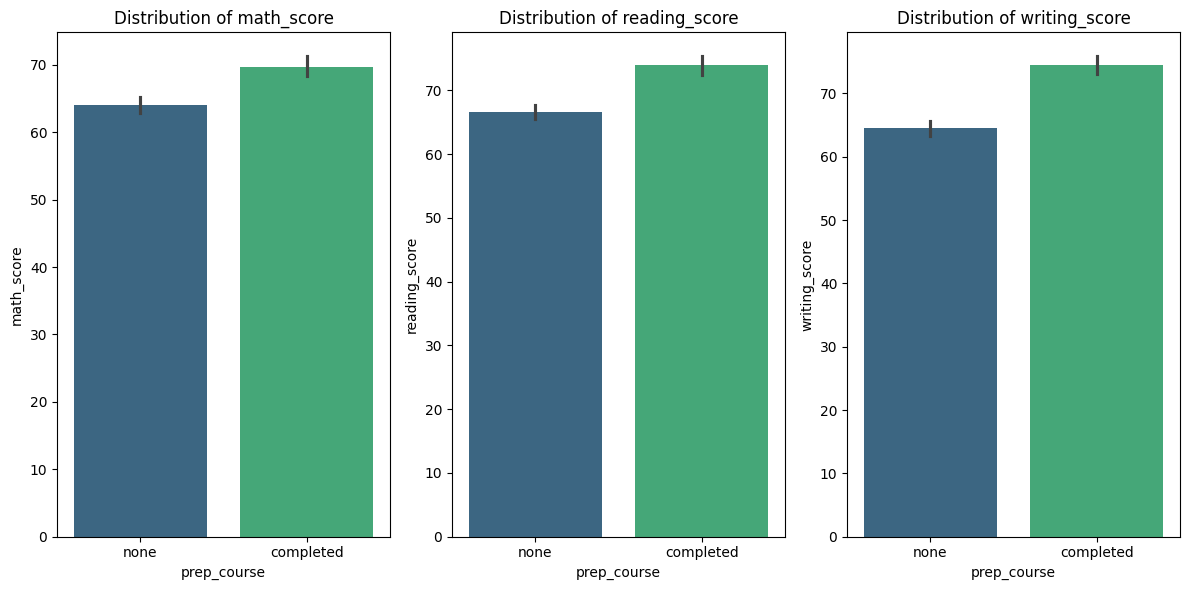

,math_score,reading_score,writing_score
prep_course,,,
completed,69.695531,73.893855,74.418994
none,64.077882,66.534268,64.504673


In [ ]:
plt.figure(figsize=(12, 6))

for i, col in enumerate(score_cols):
    plt.subplot(1, 3, i+1)
    sns.barplot(data=df, x="prep_course", y=col, palette="viridis")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

df.groupby("prep_course")[score_cols].mean()

In [ ]:
df.groupby("prep_course")["average_score"].mean()

,average_score
prep_course,
completed,72.669460
none,65.038941


### 3.3. Ethnic Origin Analysis

We observe the impact of the groups to which students belong on their exam performance.

> **Key Findings (Preparatory Course):**
> * The overall average of students who completed the course was **72.67**, whereas the average for those who did not take the course remained at **65.04**.
> * This indicates that preparatory courses play a highly critical role in enhancing student success.

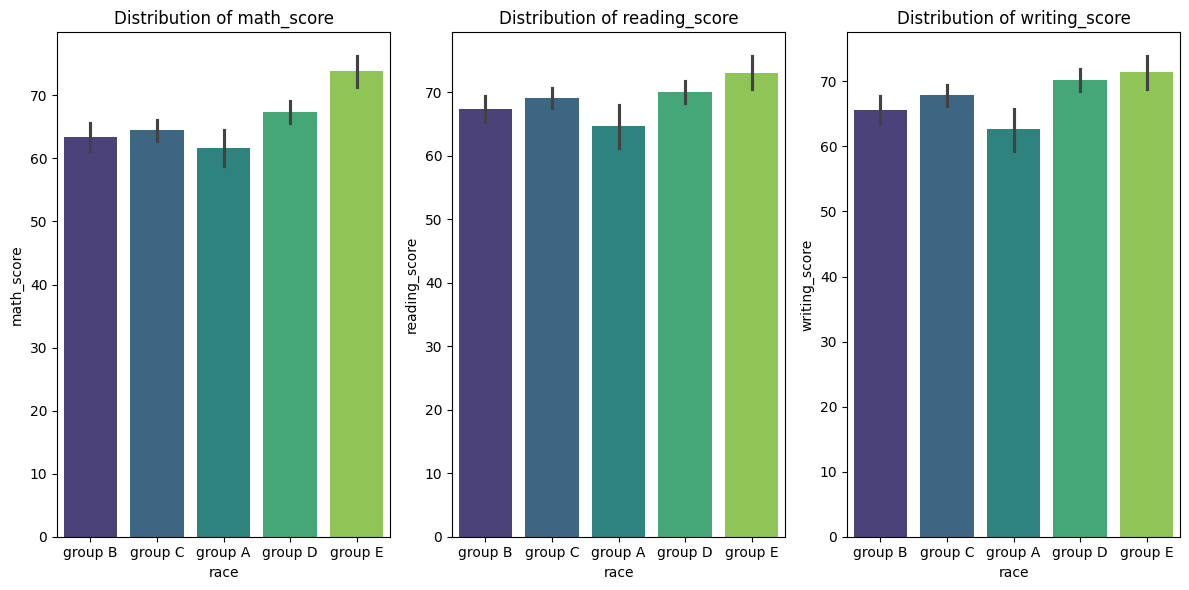

,math_score,reading_score,writing_score
race,,,
group A,61.629213,64.674157,62.674157
group B,63.452632,67.352632,65.600000
group C,64.463950,69.103448,67.827586
group D,67.362595,70.030534,70.145038
group E,73.821429,73.028571,71.407143


In [ ]:
plt.figure(figsize=(12, 6))

for i, col in enumerate(score_cols):
    plt.subplot(1, 3, i+1)
    sns.barplot(data=df, x="race", y=col, palette="viridis")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

df.groupby("race")[score_cols].mean()

In [ ]:
df.groupby("race")["average_score"].mean()

,average_score
race,
group A,62.992509
group B,65.468421
group C,67.131661
group D,69.179389
group E,72.752381


### 3.4. Analysis of Parental Level of Education

We analyze the impact of families' educational levels on students' academic outcomes.

> **Key Findings (Ethnicity):**
> * **Group E** has the highest average (72.75), while **Group A** stands out as the group with the lowest average (62.99).

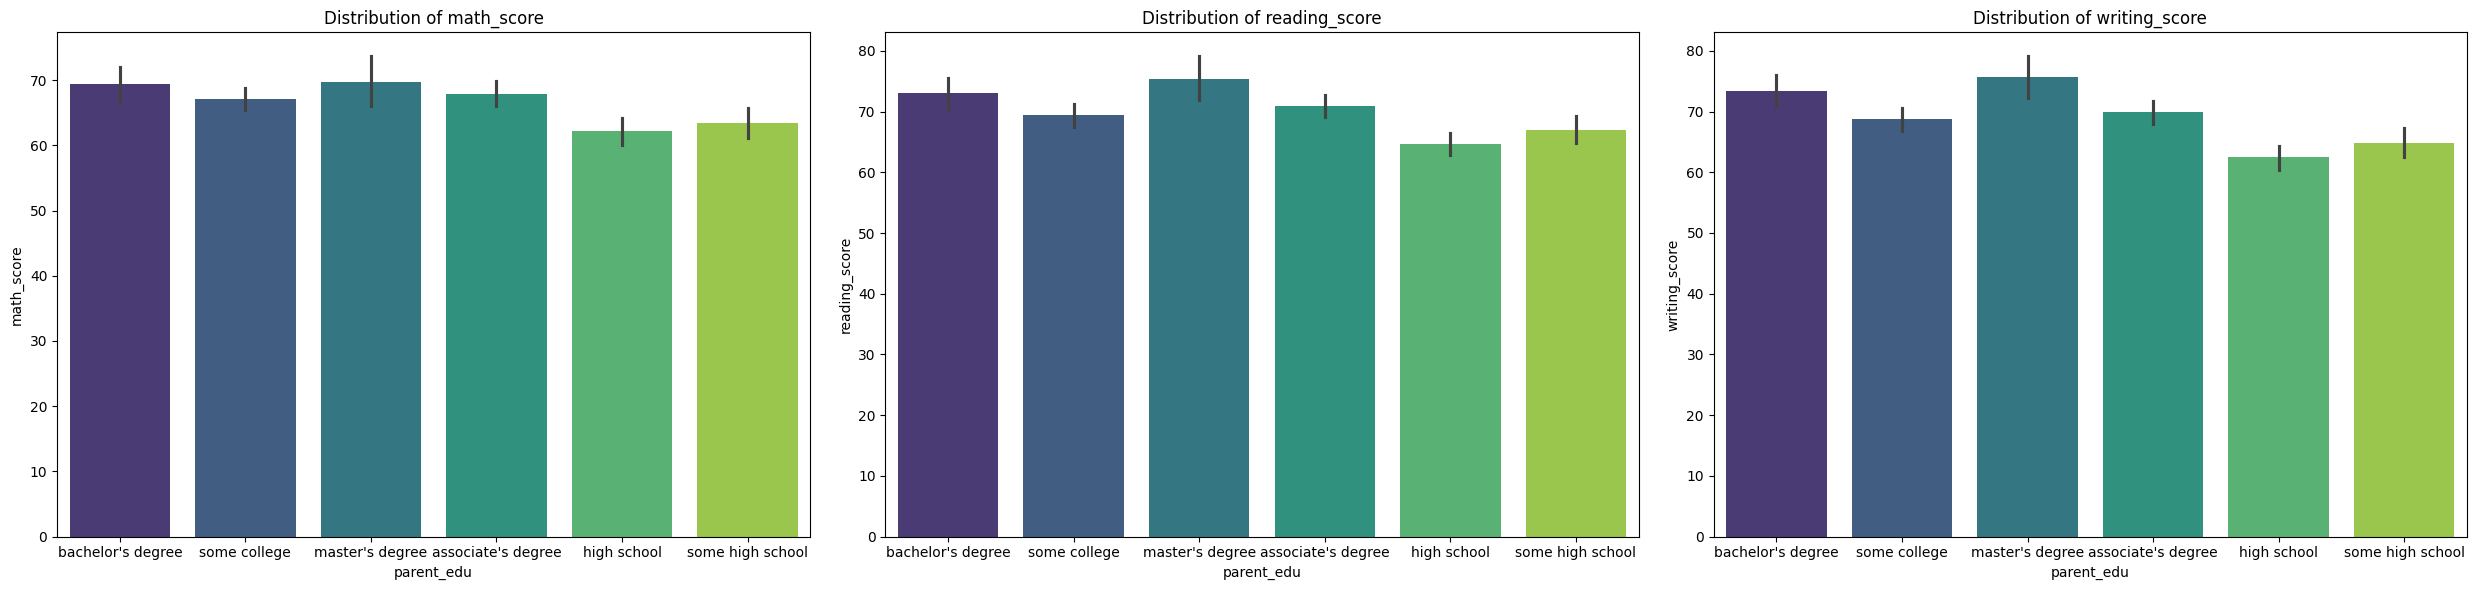

,math_score,reading_score,writing_score
parent_edu,,,
associate's degree,67.882883,70.927928,69.896396
bachelor's degree,69.389831,73.000000,73.381356
high school,62.137755,64.704082,62.448980
master's degree,69.745763,75.372881,75.677966
some college,67.128319,69.460177,68.840708
some high school,63.497207,66.938547,64.888268


In [ ]:
plt.figure(figsize=(25, 6))

for i, col in enumerate(score_cols):
    plt.subplot(1, 3, i+1)
    sns.barplot(data=df, x="parent_edu", y=col, palette="viridis")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

df.groupby("parent_edu")[score_cols].mean()

### 3.5. The Effect of Lunch Type

We evaluate the relationship between nutritional status a socio economic indicator (standard meal vs. free/reduced-price meal) and exam scores.

> **Key Findings (Parental Education):**
> * As expected, the exam performance of students whose parents hold a **Master's** or **Bachelor's** degree is significantly higher than that of students whose parents are high school graduates.

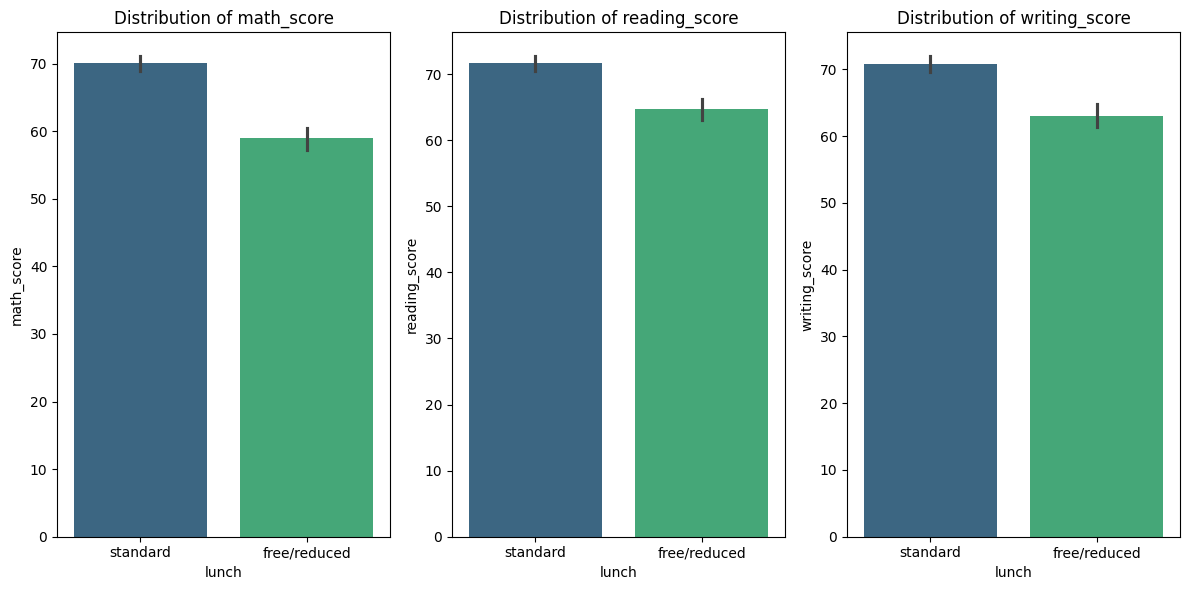

,math_score,reading_score,writing_score
lunch,,,
free/reduced,58.921127,64.653521,63.022535
standard,70.034109,71.654264,70.823256


In [ ]:
plt.figure(figsize=(12, 6))

for i, col in enumerate(score_cols):
    plt.subplot(1, 3, i+1)
    sns.barplot(data=df, x="lunch", y=col, palette="viridis")
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

df.groupby("lunch")[score_cols].mean()


## 4. Relationships Between Scores (Correlation Analysis)

We measure the linear relationships between the mathematics, reading, and writing exam results using a heatmap.

> **Key Findings (Nutrition/Lunch):**
> * The average academic performance of students with access to standard lunch options is approximately 10–12 points higher across all subjects compared to their peers receiving free or reduced-price meals. This demonstrates the direct impact of socio-economic conditions on educational achievement.

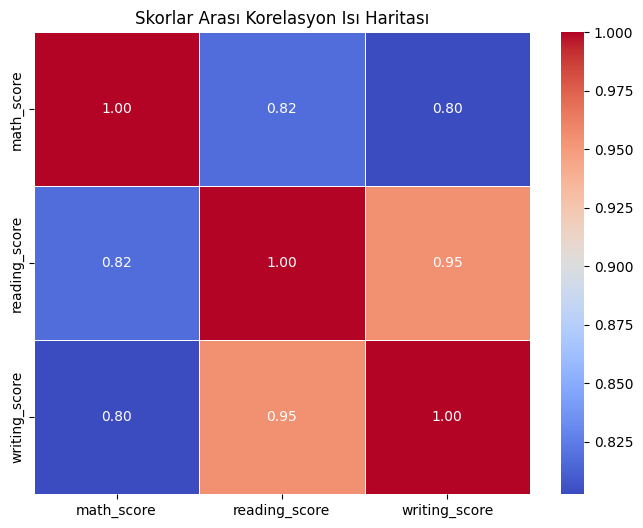

In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[['math_score', 'reading_score', 'writing_score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Skorlar Arası Korelasyon Isı Haritası')
plt.show()

> **Önemli Bulgular (Korelasyon):**
> * **Okuma (Reading) ve Yazma (Writing)** skorları arasında **0.95** gibi son derece güçlü bir pozitif ilişki bulunmaktadır. Bu iki beceri birbirini doğrudan desteklemektedir.
> * Matematik skorunun okuma (0.82) ve yazma (0.80) ile olan ilişkisi de oldukça güçlüdür.

### Ortalama Skora Göre Kategorik Değişkenlerin İncelenmesi

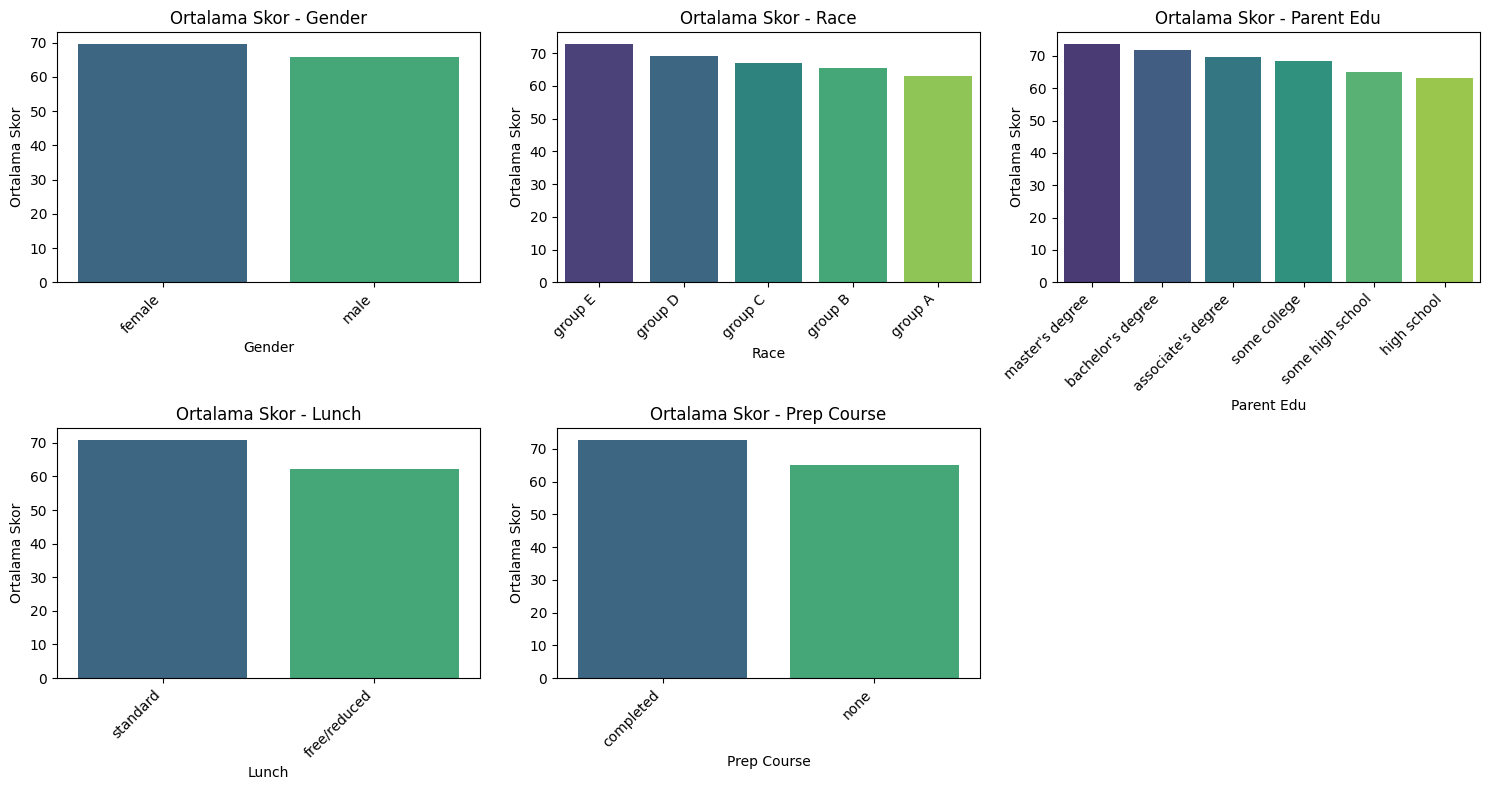

In [ ]:
categorical_cols = ['gender', 'race', 'parent_edu', 'lunch', 'prep_course']

# Calculate the number of rows and columns for the subplots dynamically
num_cols = 3 # You can adjust this for desired layout
num_rows = (len(categorical_cols) + num_cols - 1) // num_cols # Ceiling division

plt.figure(figsize=(num_cols * 5, num_rows * 4))

for i, col in enumerate(categorical_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    avg_scores_by_cat = df.groupby(col)['average_score'].mean().sort_values(ascending=False)
    sns.barplot(x=avg_scores_by_cat.index, y=avg_scores_by_cat.values, palette='viridis')
    plt.title(f'Ortalama Skor - {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Ortalama Skor')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout()
plt.show()

## 5. General Conclusion and Evaluation

In this study, demographic, socio-economic, and individual factors affecting student achievement were analyzed in depth. Based on the findings, the following key conclusions were reached:

1. **Importance of Exam Preparation Courses:** It was observed that students who completed the exam preparation course consistently outperformed those who did not across all subjects. This demonstrates the direct benefit of supplementary educational programs.
2. **Impact of Socio-Economic Status (Lunch Type):** The fact that students with access to standard lunches achieved significantly higher scores than those receiving free or reduced-price meals confirms the strong link between socio-economic resources and academic success.
3. **Parental Education Level:** Students' average academic achievement increases as their parents' education level rises (particularly at the Bachelor's and Master's degree levels). The level of education within the family is a significant determinant of student success.
4. **Inter-Subject Relationships:** A near-perfect correlation (0.95) was found between reading and writing skills, indicating that these two verbal domains directly reinforce one another. Mathematics achievement also shows a strong relationship with verbal skills.
5. **Gender Differences:** While female students demonstrated higher achievement in verbal-heavy subjects (reading and writing), male students outperformed them in the quantitative field (mathematics). However, when looking at the overall average, female students were found to be slightly ahead. ### Recommendations:
* **Support Mechanisms:** To ensure equal opportunity, free exam preparation courses and academic support should be prioritized for students from socio-economically disadvantaged backgrounds (i.e., those receiving free or subsidized school lunches).
* **Holistic Development:** Curricula should be designed in an integrated manner, as activities aimed at enhancing verbal skills (reading and writing) will also indirectly support mathematical problem-solving and comprehension abilities.